# 残基ごとの RSCC 計算

PDB ID を入力として、RCSB から PDB ファイルと Structure Factor を取得し、
Phenix `real_space_correlation` で残基ごとの Real-Space Correlation Coefficient (RSCC) を計算します。

**出力 CSV 列:** chain_id, residue_number, residue_name, rscc

**必要なソフトウェア (Mac):**
- [Phenix](https://phenix-online.org/) (`phenix.real_space_correlation`)
- [CCP4](https://www.ccp4.ac.uk/) または [GEMMI](https://github.com/project-gemmi/gemmi) (`gemmi cif2mtz`)

各セルは独立したステップです。順番に実行し、中間結果を確認してください。

## Step 0: Python 依存パッケージ

初回のみ実行してください（`pandas`, `matplotlib`）。

In [20]:
import importlib.util
import subprocess
import sys

REQUIRED = ["pandas", "matplotlib"]
missing = [pkg for pkg in REQUIRED if importlib.util.find_spec(pkg) is None]

if missing:
    print(f"Installing: {', '.join(missing)}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("All required Python packages are already installed.")


All required Python packages are already installed.


## Step 1: 入力パラメータの設定

PDB ID のみを指定します（4文字、大文字小文字は問いません）。

In [21]:
from pathlib import Path

# ===== ここを変更 =====
PDB_ID = "3klr"
# =====================

PDB_ID = PDB_ID.strip().lower()
if len(PDB_ID) != 4 or not PDB_ID.isalnum():
    raise ValueError(f"Invalid PDB ID: {PDB_ID!r} (expected 4 alphanumeric characters)")

WORK_DIR = Path("work") / PDB_ID
WORK_DIR.mkdir(parents=True, exist_ok=True)

PDB_PATH = WORK_DIR / f"{PDB_ID}.pdb"
SF_CIF_PATH = WORK_DIR / f"{PDB_ID}-sf.cif"
MTZ_PATH = WORK_DIR / f"{PDB_ID}.mtz"
CSV_PATH_ATOM = WORK_DIR / f"{PDB_ID}_rscc_atom.csv"
CSV_PATH_HETATM = WORK_DIR / f"{PDB_ID}_rscc_hetatm.csv"

print(f"PDB ID          : {PDB_ID.upper()}")
print(f"Work dir        : {WORK_DIR.resolve()}")
print(f"PDB file        : {PDB_PATH.name}")
print(f"SF CIF          : {SF_CIF_PATH.name}")
print(f"MTZ file        : {MTZ_PATH.name}")
print(f"Output CSV ATOM : {CSV_PATH_ATOM.name}")
print(f"Output CSV HET  : {CSV_PATH_HETATM.name}")

PDB ID          : 3KLR
Work dir        : /Users/structure_analysis/github/structure_tools/RSCC/work/3klr
PDB file        : 3klr.pdb
SF CIF          : 3klr-sf.cif
MTZ file        : 3klr.mtz
Output CSV ATOM : 3klr_rscc_atom.csv
Output CSV HET  : 3klr_rscc_hetatm.csv


## Step 2: 実行環境の確認

Phenix と GEMMI (`cif2mtz`) のパスを自動検出します。

In [22]:
import glob
import shutil
from typing import Optional


def find_executable(name: str, search_patterns: list[str]) -> Optional[str]:
    """PATH または典型的な Mac のインストール先から実行ファイルを探す。"""
    found = shutil.which(name)
    if found:
        return found
    for pattern in search_patterns:
        matches = sorted(glob.glob(pattern))
        if matches:
            return matches[-1]
    return None


PHENIX_RSCC = find_executable(
    "phenix.real_space_correlation",
    ["/Applications/phenix-*/build/bin/phenix.real_space_correlation"],
)
GEMMI = find_executable(
    "gemmi",
    ["/Applications/ccp4-*/bin/gemmi", "/usr/local/bin/gemmi"],
)

print("=== Environment ===")
print(f"phenix.real_space_correlation : {PHENIX_RSCC or 'NOT FOUND'}")
print(f"gemmi                         : {GEMMI or 'NOT FOUND'}")

missing = []
if not PHENIX_RSCC:
    missing.append("Phenix (phenix.real_space_correlation)")
if not GEMMI:
    missing.append("GEMMI (gemmi cif2mtz)")

if missing:
    raise RuntimeError(
        "Required tools not found:\n  - " + "\n  - ".join(missing) + "\n"
        "Install Phenix and CCP4/GEMMI, or add them to PATH."
    )

print("\nAll required tools are available.")

=== Environment ===
phenix.real_space_correlation : /Applications/phenix-1.20.1-4487/build/bin/phenix.real_space_correlation
gemmi                         : /Applications/ccp4-8.0/bin/gemmi

All required tools are available.


## Step 3: RCSB から PDB ファイルをダウンロード

URL: `https://files.rcsb.org/download/{PDB_ID}.pdb`

In [23]:
from urllib.error import HTTPError, URLError
from urllib.request import urlopen

RCSB_BASE_URL = "https://files.rcsb.org/download"


def download_file(url: str, output_path: Path, overwrite: bool = False) -> Path:
    if output_path.exists() and not overwrite:
        print(f"Skip (already exists): {output_path}")
        return output_path

    try:
        with urlopen(url, timeout=60) as response:
            data = response.read()
    except HTTPError as exc:
        raise FileNotFoundError(f"Download failed ({exc.code}): {url}") from exc
    except URLError as exc:
        raise ConnectionError(f"Network error: {url} ({exc})") from exc

    output_path.write_bytes(data)
    print(f"Downloaded: {output_path} ({len(data):,} bytes)")
    return output_path


pdb_url = f"{RCSB_BASE_URL}/{PDB_ID}.pdb"
download_file(pdb_url, PDB_PATH)

print("\n--- PDB file preview (first 10 lines) ---")
for line in PDB_PATH.read_text(errors="replace").splitlines()[:10]:
    print(line)

Skip (already exists): work/3klr/3klr.pdb

--- PDB file preview (first 10 lines) ---
HEADER    OXIDOREDUCTASE                          09-NOV-09   3KLR              
TITLE     BOVINE H-PROTEIN AT 0.88 ANGSTROM RESOLUTION                          
COMPND    MOL_ID: 1;                                                            
COMPND   2 MOLECULE: GLYCINE CLEAVAGE SYSTEM H PROTEIN;                         
COMPND   3 CHAIN: A;                                                            
COMPND   4 ENGINEERED: YES                                                      
SOURCE    MOL_ID: 1;                                                            
SOURCE   2 ORGANISM_SCIENTIFIC: BOS TAURUS;                                     
SOURCE   3 ORGANISM_COMMON: BOVINE;                                             
SOURCE   4 ORGANISM_TAXID: 9913;                                                


## Step 4: RCSB から Structure Factor (mmCIF) をダウンロード

RCSB は MTZ を直接提供しないため、Structure Factor mmCIF (`-sf.cif`) を取得します。

URL: `https://files.rcsb.org/download/{PDB_ID}-sf.cif`

In [24]:
sf_url = f"{RCSB_BASE_URL}/{PDB_ID}-sf.cif"
download_file(sf_url, SF_CIF_PATH)

print("\n--- Structure factor CIF preview (first 15 lines) ---")
for line in SF_CIF_PATH.read_text(errors="replace").splitlines()[:15]:
    print(line)

Skip (already exists): work/3klr/3klr-sf.cif

--- Structure factor CIF preview (first 15 lines) ---
data_r3klrsf
# 
loop_
_audit.revision_id 
_audit.creation_date 
_audit.update_record 
1_0 2010-06-09 'Initial release'        
1_1 2013-10-30 'Format standardization' 
# 
_cell.entry_id      3klr 
_cell.length_a      84.584 
_cell.length_b      41.295 
_cell.length_c      43.124 
_cell.angle_alpha   90.000 
_cell.angle_beta    91.180 


## Step 5: mmCIF → MTZ 変換

Phenix は MTZ 形式の反射データを要求するため、`gemmi cif2mtz` で変換します。

In [25]:
import subprocess

if MTZ_PATH.exists():
    print(f"Skip (already exists): {MTZ_PATH}")
else:
    cmd = [GEMMI, "cif2mtz", str(SF_CIF_PATH), str(MTZ_PATH)]
    print("Command:", " ".join(cmd))
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print(result.stdout)
        print(result.stderr)
        raise RuntimeError(f"gemmi cif2mtz failed (exit {result.returncode})")
    if result.stdout.strip():
        print(result.stdout)
    print(f"Created: {MTZ_PATH} ({MTZ_PATH.stat().st_size:,} bytes)")

mtz_info = subprocess.run(
    [GEMMI, "mtz", str(MTZ_PATH)],
    capture_output=True,
    text=True,
    check=True,
)
print("\n--- MTZ file info ---")
print(mtz_info.stdout[:2000] if len(mtz_info.stdout) > 2000 else mtz_info.stdout)

Skip (already exists): work/3klr/3klr.mtz

--- MTZ file info ---
Title: Converted from mmCIF block r3klrsf
Total Number of Datasets = 2

Dataset    0   HKL_base > HKL_base > HKL_base:
        cell  84.584  41.295  43.124      90  91.18     90
  wavelength  0
Dataset    1   unknown > unknown > unknown:
        cell  84.584  41.295  43.124      90  91.18     90
  wavelength  1

Number of Columns = 6
Number of Reflections = 115668
Number of Batches = 0
Missing values marked as: nan
Global Cell (obsolete):  84.584  41.295  43.124      90  91.18     90
Resolution: 0.88 - 43.11 A
Sort Order: 0 0 0 0 0
Space Group: C 1 2 1
Space Group Number: 5

Header info (run with option -s for recalculated statistics):
Column    Type  Dataset    Min        Max
H            H  0          -95         95
K            H  0            0         45
L            H  0            0         48
FreeR_flag   I  0            0          1
IMEAN        J  1      -385.44     670561
SIGIMEAN     Q  1          1.2      149

## Step 6: Phenix で残基ごとの RSCC を計算

`phenix.real_space_correlation` を `detail=residue` で実行します。

※ 構造のサイズによっては数分かかることがあります。

In [26]:
cmd = [
    PHENIX_RSCC,
    str(PDB_PATH),
    str(MTZ_PATH),
    "detail=residue",
]
print("Command:", " ".join(cmd))
print("Running... (this may take a few minutes)\n")

result = subprocess.run(cmd, capture_output=True, text=True)
PHENIX_STDOUT = result.stdout
PHENIX_STDERR = result.stderr

if result.returncode != 0:
    print("=== STDERR ===")
    print(PHENIX_STDERR[-3000:] if len(PHENIX_STDERR) > 3000 else PHENIX_STDERR)
    print("\n=== STDOUT (tail) ===")
    print(PHENIX_STDOUT[-3000:] if len(PHENIX_STDOUT) > 3000 else PHENIX_STDOUT)
    raise RuntimeError(f"phenix.real_space_correlation failed (exit {result.returncode})")

if PHENIX_STDERR.strip():
    print("=== STDERR (informational) ===")
    print(PHENIX_STDERR[-1000:] if len(PHENIX_STDERR) > 1000 else PHENIX_STDERR)

print("\n--- Phenix output (last 25 lines) ---")
stdout_lines = PHENIX_STDOUT.splitlines()
for line in stdout_lines[-25:]:
    print(line)

print(f"\nTotal output lines: {len(stdout_lines)}")

Command: /Applications/phenix-1.20.1-4487/build/bin/phenix.real_space_correlation work/3klr/3klr.pdb work/3klr/3klr.mtz detail=residue
Running... (this may take a few minutes)


--- Phenix output (last 25 lines) ---
 A   HOH  366   0.88   26.68  0.8300   2.80   2.39
 A   HOH  367   0.96   30.57  0.9235   2.56   2.44
 A   HOH  368   0.62   25.20  0.8980   2.00   2.42
 A   HOH  369   1.00   37.02  0.8589   2.60   2.29
 A   HOH  370   0.51   17.76  0.9230   2.51   2.56
 A   HOH  371   0.96   14.02  0.9935   6.77   7.00
 A   HOH  372   0.64   23.14  0.9323   2.23   2.63
 A   HOH  373   1.00   34.82  0.8783   2.46   2.86
 A   HOH  374   1.00   40.52  0.8204   2.17   1.70
 A   HOH  375   0.52   13.49  0.9626   3.67   3.40
 A   HOH  376   0.67   21.83  0.9410   2.68   2.66
 A   HOH  377   0.49   17.68  0.8821   2.48   2.50
 A   HOH  378   0.42   12.55  0.9572   3.06   3.18
 A   HOH  379   1.00   33.23  0.8700   2.56   2.15
 A   HOH  380   0.83   24.21  0.9445   3.04   2.92
 A   HOH  381   1.0

## Step 7: Phenix 出力をパースして DataFrame を作成

残基テーブル (`<id string>  occ  ADP  CC  Rho1  Rho2`) を解析します。

PDB ファイルの `ATOM` / `HETATM` 行を参照し、各残基をアミノ酸（ATOM）か低分子（HETATM）に分類します。

In [27]:
from dataclasses import dataclass
from typing import Dict, List, Tuple

import pandas as pd

TABLE_HEADER = "<id string>"
ResidueKey = Tuple[str, str, str]


@dataclass
class RsccRecord:
    chain_id: str
    altloc: str
    residue_name: str
    residue_number: str
    occ: float
    adp: float
    rscc: float
    rho1: float
    rho2: float


def parse_pdb_residue_types(pdb_path: Path) -> Dict[ResidueKey, str]:
    """PDB の ATOM/HETATM 行から (chain, residue_number, residue_name) -> record_type を返す。"""
    residue_types: Dict[ResidueKey, str] = {}
    for line in pdb_path.read_text(errors="replace").splitlines():
        record = line[:6].strip()
        if record not in {"ATOM", "HETATM"}:
            continue
        chain_id = line[21:22].strip() or "_"
        residue_name = line[17:20].strip()
        residue_number = line[22:26].strip()
        key = (chain_id, residue_number, residue_name)
        if key not in residue_types:
            residue_types[key] = record
        elif record == "ATOM" and residue_types[key] == "HETATM":
            residue_types[key] = "ATOM"
    return residue_types


def parse_phenix_rscc_output(stdout: str) -> List[RsccRecord]:
    """phenix.real_space_correlation detail=residue の stdout から残基 RSCC を抽出。"""
    lines = stdout.splitlines()
    table_started = False
    records: List[RsccRecord] = []

    for line in lines:
        if TABLE_HEADER in line:
            table_started = True
            continue
        if not table_started or not line.strip():
            continue

        parts = line.split()
        if len(parts) == 8:
            chain_id, residue_name, residue_number, occ, adp, rscc, rho1, rho2 = parts
            altloc = ""
        elif len(parts) == 9:
            chain_id, altloc, residue_name, residue_number, occ, adp, rscc, rho1, rho2 = parts
        else:
            continue

        try:
            records.append(
                RsccRecord(
                    chain_id=chain_id,
                    altloc=altloc,
                    residue_name=residue_name,
                    residue_number=residue_number,
                    occ=float(occ),
                    adp=float(adp),
                    rscc=float(rscc),
                    rho1=float(rho1),
                    rho2=float(rho2),
                )
            )
        except ValueError:
            continue

    if not records:
        raise ValueError(
            "No residue RSCC records found in Phenix output. "
            "Check that detail=residue was used and the run completed successfully."
        )
    return records


records = parse_phenix_rscc_output(PHENIX_STDOUT)
pdb_residue_types = parse_pdb_residue_types(PDB_PATH)

df = pd.DataFrame(
    {
        "chain_id": [r.chain_id for r in records],
        "residue_number": [r.residue_number for r in records],
        "residue_name": [r.residue_name for r in records],
        "rscc": [r.rscc for r in records],
    }
)

df["record_type"] = df.apply(
    lambda row: pdb_residue_types.get(
        (row["chain_id"], str(row["residue_number"]), row["residue_name"]),
        "UNKNOWN",
    ),
    axis=1,
)

df_atom = df[df["record_type"] == "ATOM"].copy()
df_hetatm = df[df["record_type"] == "HETATM"].copy()
df_unknown = df[df["record_type"] == "UNKNOWN"].copy()

print(f"Parsed {len(df)} residue records")
print(f"  ATOM   : {len(df_atom)}")
print(f"  HETATM : {len(df_hetatm)}")
if len(df_unknown):
    print(f"  UNKNOWN: {len(df_unknown)} (PDB と一致しなかった残基)")

print(f"\nRSCC summary (ATOM):\n{df_atom['rscc'].describe()}")
print(f"\nRSCC summary (HETATM):\n{df_hetatm['rscc'].describe()}")
print("\n--- ATOM: first 10 rows ---")
df_atom.head(10)

Parsed 430 residue records
  ATOM   : 157
  HETATM : 273

RSCC summary (ATOM):
count    157.000000
mean       0.986197
std        0.021143
min        0.737500
25%        0.984500
50%        0.989400
75%        0.992000
max        0.997600
Name: rscc, dtype: float64

RSCC summary (HETATM):
count    273.000000
mean       0.878468
std        0.137922
min        0.311000
25%        0.828000
50%        0.923400
75%        0.976900
max        0.998700
Name: rscc, dtype: float64

--- ATOM: first 10 rows ---


,chain_id,residue_number,residue_name,rscc,record_type
0,A,1,SER,0.7375,ATOM
1,A,2,VAL,0.9362,ATOM
2,A,3,ARG,0.9668,ATOM
3,A,4,LYS,0.9774,ATOM
4,A,5,PHE,0.9899,ATOM
5,A,6,THR,0.9939,ATOM
6,A,7,GLU,0.9845,ATOM
7,A,7,GLU,0.9878,ATOM
8,A,8,LYS,0.9899,ATOM
9,A,9,HIS,0.9897,ATOM


## Step 8: CSV 出力（ATOM / HETATM 分離）

- `{PDB_ID}_rscc_atom.csv` — アミノ酸残基（PDB `ATOM` 行）
- `{PDB_ID}_rscc_hetatm.csv` — 低分子（PDB `HETATM` 行: HOH, リガンド, イオン等）

列: `chain_id`, `residue_number`, `residue_name`, `rscc`

In [28]:
OUTPUT_COLUMNS = ["chain_id", "residue_number", "residue_name", "rscc"]


def save_rscc_csv(dataframe: pd.DataFrame, path: Path, label: str) -> None:
    dataframe[OUTPUT_COLUMNS].to_csv(path, index=False)
    print(f"Saved ({label}): {path.resolve()}  ({len(dataframe)} rows)")


save_rscc_csv(df_atom, CSV_PATH_ATOM, "ATOM")
save_rscc_csv(df_hetatm, CSV_PATH_HETATM, "HETATM")

if len(df_unknown):
    csv_unknown = WORK_DIR / f"{PDB_ID}_rscc_unknown.csv"
    save_rscc_csv(df_unknown, csv_unknown, "UNKNOWN")

print("\n--- ATOM CSV preview (first 5 lines) ---")
for line in CSV_PATH_ATOM.read_text().splitlines()[:6]:
    print(line)

print("\n--- HETATM CSV preview (first 5 lines) ---")
for line in CSV_PATH_HETATM.read_text().splitlines()[:6]:
    print(line)

Saved (ATOM): /Users/structure_analysis/github/structure_tools/RSCC/work/3klr/3klr_rscc_atom.csv  (157 rows)
Saved (HETATM): /Users/structure_analysis/github/structure_tools/RSCC/work/3klr/3klr_rscc_hetatm.csv  (273 rows)

--- ATOM CSV preview (first 5 lines) ---
chain_id,residue_number,residue_name,rscc
A,1,SER,0.7375
A,2,VAL,0.9362
A,3,ARG,0.9668
A,4,LYS,0.9774
A,5,PHE,0.9899

--- HETATM CSV preview (first 5 lines) ---
chain_id,residue_number,residue_name,rscc
A,2001,SO4,0.8559
A,2002,SO4,0.9234
A,2003,GOL,0.9749
A,2003,GOL,0.9628
A,126,HOH,0.929


## (Optional) Step 9: RSCC 分布の可視化（ATOM / HETATM 分離）

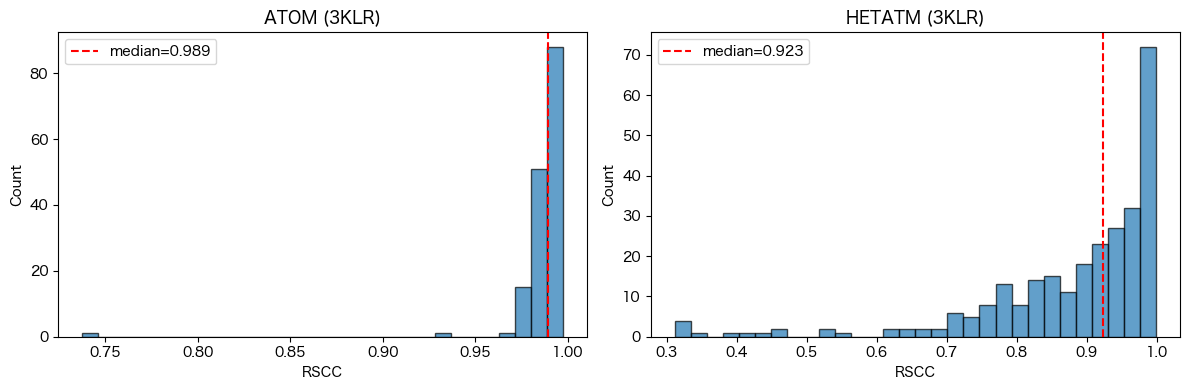

In [ ]:
import matplotlib.pyplot as plt

if "configure_matplotlib_japanese" not in globals():
    configure_matplotlib_japanese()
else:
    configure_matplotlib_japanese()


def plot_rscc_histogram(dataframe: pd.DataFrame, title: str, ax) -> None:
    if dataframe.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        return
    ax.hist(dataframe["rscc"], bins=30, edgecolor="black", alpha=0.7)
    ax.axvline(
        dataframe["rscc"].median(),
        color="red",
        linestyle="--",
        label=f"median={dataframe['rscc'].median():.3f}",
    )
    ax.set_xlabel("RSCC")
    ax.set_ylabel("Count")
    ax.set_title(title)
    ax.legend()


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_rscc_histogram(df_atom, f"ATOM ({PDB_ID.upper()})", axes[0])
plot_rscc_histogram(df_hetatm, f"HETATM ({PDB_ID.upper()})", axes[1])
plt.tight_layout()
plt.show()

## (Optional) Step 10: 残基番号 vs RSCC プロット（ATOM / HETATM 分離）

横軸: 残基番号、縦軸: RSCC。chain ID ごとに色分けして表示します。

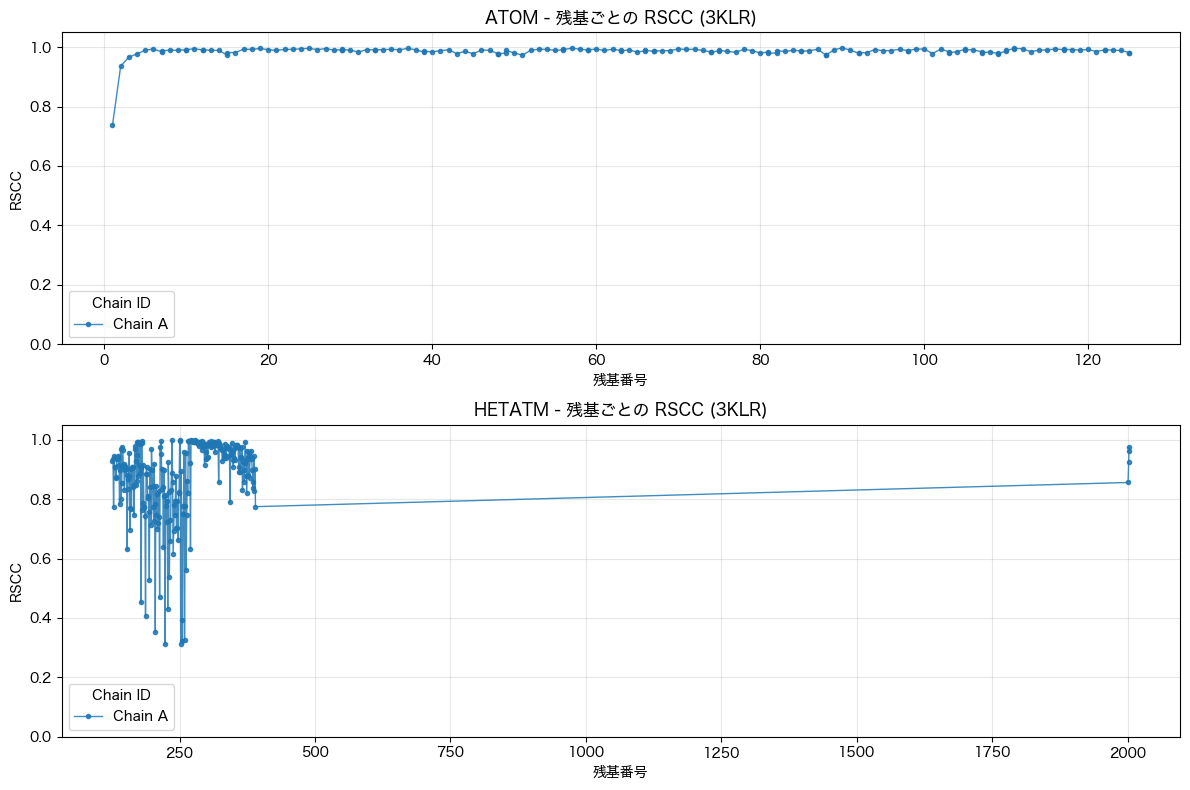

In [ ]:
import matplotlib
from matplotlib import font_manager
import matplotlib.pyplot as plt

if "configure_matplotlib_japanese" not in globals():
    def configure_matplotlib_japanese() -> str:
        candidates = [
            "Hiragino Sans",
            "Hiragino Kaku Gothic ProN",
            "Hiragino Kaku Gothic Pro",
            "AppleGothic",
            "Arial Unicode MS",
            "Noto Sans CJK JP",
        ]
        available = {f.name for f in font_manager.fontManager.ttflist}
        for font_name in candidates:
            if font_name in available:
                matplotlib.rcParams["font.family"] = font_name
                matplotlib.rcParams["axes.unicode_minus"] = False
                return font_name
        matplotlib.rcParams["axes.unicode_minus"] = False
        return "default"

configure_matplotlib_japanese()


def plot_rscc_by_residue(dataframe: pd.DataFrame, title: str, ax) -> None:
    if dataframe.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        return

    plot_df = dataframe.copy()
    plot_df["residue_num"] = pd.to_numeric(plot_df["residue_number"], errors="coerce")

    for chain_id, group in plot_df.groupby("chain_id", sort=True):
        group = group.sort_values(["residue_num", "residue_number"])
        ax.plot(
            group["residue_num"],
            group["rscc"],
            marker="o",
            markersize=3,
            linewidth=1,
            label=f"Chain {chain_id}",
            alpha=0.85,
        )

    ax.set_xlabel("残基番号")
    ax.set_ylabel("RSCC")
    ax.set_title(title)
    ax.set_ylim(0, 1.05)
    ax.legend(title="Chain ID")
    ax.grid(True, alpha=0.3)


fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)
plot_rscc_by_residue(df_atom, f"ATOM — 残基ごとの RSCC ({PDB_ID.upper()})", axes[0])
plot_rscc_by_residue(df_hetatm, f"HETATM — 残基ごとの RSCC ({PDB_ID.upper()})", axes[1])
plt.tight_layout()
plt.show()